In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv('./Clean_Dataset.csv')
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [38]:
df = df.drop(columns=['Unnamed: 0', 'flight'], axis=1)
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [39]:
df.airline.value_counts()

# There are only 6 airlines in the dataset, so we can use one-hot encoding to convert the airline column into 6 columns
# The same for cities because there's not so many cities in the dataset
# The same with the departure and arrival time

# One-hot encoding
df = pd.get_dummies(df, columns=['airline'])
print(df.head())

# OR
# df = df.join(pd.get_dummies(df['airline'], prefix='airline')).drop(['airline'], axis=1)

  source_city departure_time stops   arrival_time destination_city    class  \
0       Delhi        Evening  zero          Night           Mumbai  Economy   
1       Delhi  Early_Morning  zero        Morning           Mumbai  Economy   
2       Delhi  Early_Morning  zero  Early_Morning           Mumbai  Economy   
3       Delhi        Morning  zero      Afternoon           Mumbai  Economy   
4       Delhi        Morning  zero        Morning           Mumbai  Economy   

   duration  days_left  price  airline_AirAsia  airline_Air_India  \
0      2.17          1   5953            False              False   
1      2.33          1   5953            False              False   
2      2.17          1   5956             True              False   
3      2.25          1   5955            False              False   
4      2.33          1   5955            False              False   

   airline_GO_FIRST  airline_Indigo  airline_SpiceJet  airline_Vistara  
0             False           False  

In [40]:
df.stops.value_counts()

# In this case there are 3 values so we can do ordinal encoding
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# OR
# df['stops'] = df['stops'].replace({'zero': 0, 'one': 1, 'two_or_more': 2})

# OR
# df['stops'] = df['stops'].apply(lambda x: 0 if x == 'zero' else 1 if x == 'one' else 2)

# OR
# df['stops'] = df['stops'].apply(lambda x: {'zero': 0, 'one': 1, 'two_or_more': 2}[x])

# OR
# df['stops'] = df['stops'].apply({'zero': 0, 'one': 1, 'two_or_more': 2}.get)

# OR
# pd.factorize(df['stops'])

In [41]:
df['class'].value_counts()

# If we have 2 features we can do binary encoding. It's not one-hot encoding because we have only 2 values.
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

# OR

# df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)
df

,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara
0,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953,False,False,False,False,True,False
1,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953,False,False,False,False,True,False
2,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956,True,False,False,False,False,False
3,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955,False,False,False,False,False,True
4,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265,False,False,False,False,False,True
300149,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105,False,False,False,False,False,True
300150,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099,False,False,False,False,False,True
300151,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585,False,False,False,False,False,True


In [43]:
# Need to encode source_city, destination_city, departure_time, arrival_time

# One-hot encoding
df = df.join(pd.get_dummies(df['source_city'], prefix='source_city')).drop(['source_city'], axis=1)
df = df.join(pd.get_dummies(df['destination_city'], prefix='destination_city')).drop(['destination_city'], axis=1)
df = df.join(pd.get_dummies(df['departure_time'], prefix='departure_time')).drop(['departure_time'], axis=1)
df = df.join(pd.get_dummies(df['arrival_time'], prefix='arrival_time')).drop(['arrival_time'], axis=1)


In [44]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
300151,1,1,10.00,49,81585,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [45]:
# Training regression model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['price'], axis=1)
y = df['price']
X

,stops,class,duration,days_left,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,0,2.17,1,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True
1,0,0,2.33,1,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,2.17,1,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,False,False,False,False,False,True,...,False,False,True,False,True,False,False,False,False,False
4,0,0,2.33,1,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False
300149,1,1,10.42,49,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
300150,1,1,13.83,49,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
300151,1,1,10.00,49,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
reg = RandomForestRegressor(n_jobs=-1, random_state=42)
reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [49]:
reg.score(X_test, y_test)

0.9849313061088417

In [50]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', math.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score:', r2_score(y_test, y_pred))

Mean Absolute Error: 1077.4944121460524
Mean Squared Error: 7767644.586727666
Root Mean Squared Error: 2787.049441026776
R2 Score: 0.9849313061088417


Text(0.5, 1.0, 'Actual Price vs Predicted Price')

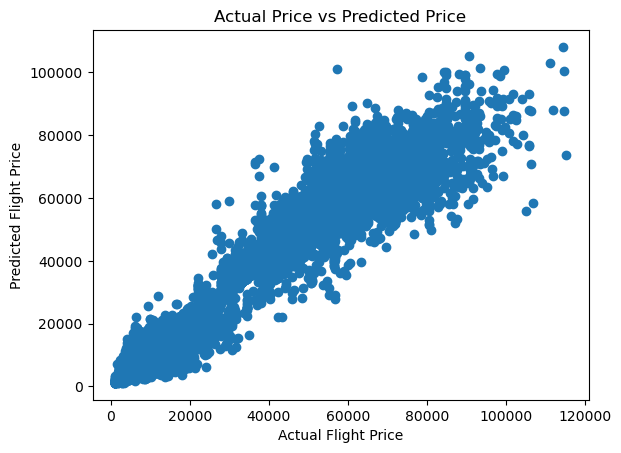

In [51]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Actual Price vs Predicted Price')

In [52]:
important_features_dict = {}   

for idx, val in enumerate(reg.feature_importances_):
    important_features_dict[X.columns[idx]] = val

important_features_list = sorted(important_features_dict.items(), key=lambda x: x[1], reverse=True)

print(f'5 most important features: {important_features_list[:5]}')

5 most important features: [('class', 0.8798560857287681), ('duration', 0.057795668346049475), ('days_left', 0.01851131654728923), ('airline_Air_India', 0.0051566312267162535), ('airline_Vistara', 0.004806062919667252)]


<BarContainer object of 5 artists>

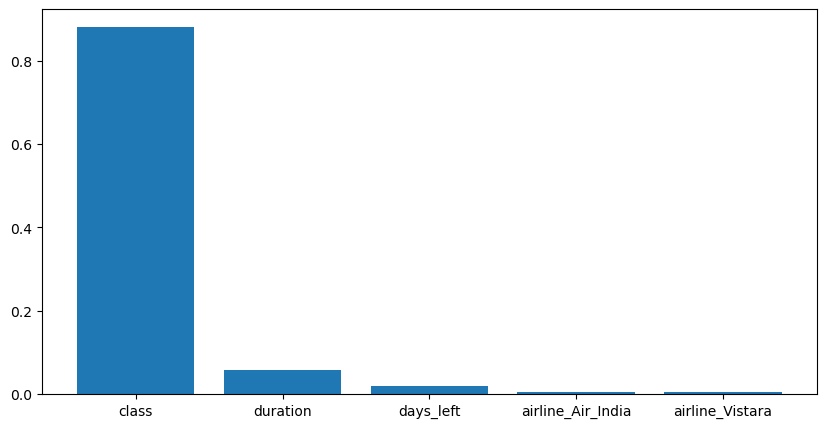

In [55]:
plt.figure(figsize=(10, 5))
#plt.bar(range(len(important_features_dict)), list(important_features_dict.values()), align='center')
#plt.bar(range(5), [val[1] for val in important_features_list[:5]], align='center')
plt.bar([x[0] for x in important_features_list[:5]], [x[1] for x in important_features_list[:5]])

In [57]:
# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

grid_search = GridSearchCV(estimator=reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_params

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [58]:
# Becaues GridSearchCV takes so much time, we can use RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [60]:
param_dict = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(10, 100),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['auto', 'sqrt']
}

In [62]:
reg = RandomForestRegressor(n_jobs=-1, random_state=42)

random_search = RandomizedSearchCV(estimator=reg, param_distributions=param_dict, n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='neg_mean_squared_error')
random_search.fit(X_train, y_train)

best_regressor = random_search.best_estimator_
best_params = random_search.best_params_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=70, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.0s
[CV] END max_depth=70, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.1s
[CV] END max_depth=61, max_features=auto, min_samples_leaf=15, min_samples_split=12, n_estimators=171; total time=   0.1s
[CV] END max_depth=70, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.2s
[CV] END max_depth=61, max_features=auto, min_samples_leaf=15, min_samples_split=12, n_estimators=171; total time=   0.2s
[CV] END max_depth=61, max_features=auto, min_samples_leaf=15, min_samples_split=12, n_estimators=171; total time=   0.2s
[CV] END max_depth=61, max_features=auto, min_samples_leaf=15, min_samples_split=12, n_estimators=171; total time=   0.1s
[CV] END max_depth=61, max_features=auto, min_samples_leaf=15, min_samples_split=12, n

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=56, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=104; total time=  24.8s
[CV] END max_depth=56, max_features=sqrt, min_samples_leaf=3, min_samples_split=2, n_estimators=104; total time=  23.6s
[CV] END max_depth=24, max_features=auto, min_samples_leaf=4, min_samples_split=14, n_estimators=259; total time=   0.1s
[CV] END max_depth=24, max_features=auto, min_samples_leaf=4, min_samples_split=14, n_estimators=259; total time=   0.1s
[CV] END max_depth=24, max_features=auto, min_samples_leaf=4, min_samples_split=14, n_estimators=259; total time=   0.1s
[CV] END max_depth=24, max_features=auto, min_samples_leaf=4, min_samples_split=14, n_estimators=259; total time=   0.1s
[CV] END max_depth=80, max_features=auto, min_samples_leaf=19, min_samples_split=3, n_estimators=269; total time=   0.1s
[CV] END max_depth=80, max_features=auto, min_samples_leaf=19, min_samples_split=3, n_estimators=269; total time=   0.0s
[CV] END max_depth=80, max_feature

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
245 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
161 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py", line 666, in _validate_par